### Healthcare Readmission Analytics

#### Notebook 05 — Baseline Machine Learning Models

#### Purpose
#####
This notebook builds baseline machine learning models to predict hospital readmission.

The goals are:

- load the modeling dataset
- split data into training and testing sets
- train baseline classification models
- evaluate model performance
- compare model results
- save model outputs for future reporting

#### Why This Matters
#####
Baseline models help establish the first performance benchmark.

Before improving models, we need to understand how simple models perform.

Import Libraries

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

Load Modeling Dataset

In [2]:
# ============================================
# LOAD MODELING DATASET
# ============================================

df = pd.read_csv("../data/processed/modeling_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (101766, 12)


,age_numeric,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,total_utilization,high_medication_count,readmitted_flag
0,5,1,41,0,1,0,0,0,1,0,0,0
1,15,3,59,0,18,0,0,0,9,0,1,1
2,25,2,11,5,13,2,0,1,6,3,0,0
3,35,2,44,1,16,0,0,0,7,0,1,0
4,45,1,51,0,8,0,0,0,5,0,0,0


Define Features and Target

In [3]:
# ============================================
# DEFINE FEATURES AND TARGET
# ============================================

X = df.drop(columns=["readmitted_flag"])
y = df["readmitted_flag"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (101766, 11)
Target Shape: (101766,)


Check Target Balance

In [4]:
# ============================================
# TARGET DISTRIBUTION
# ============================================

target_counts = y.value_counts()
target_percent = y.value_counts(normalize=True).mul(100).round(2)

print(target_counts)
print(target_percent)

readmitted_flag
0    54864
1    46902
Name: count, dtype: int64
readmitted_flag
0    53.91
1    46.09
Name: proportion, dtype: float64


Target Balance

The target variable shows whether a patient was readmitted.

Checking target balance helps determine whether accuracy alone is enough for evaluation.

If one class dominates, precision, recall, and F1-score become more important.

Train-Test Split

In [5]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81412, 11)
X_test: (20354, 11)
y_train: (81412,)
y_test: (20354,)


Why Stratify? 

Stratification keeps the readmitted and non-readmitted class proportions similar in both training and testing data.

Scale Data for Logistic Regression

In [6]:
# ============================================
# SCALE NUMERIC FEATURES
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Logistic Regression is sensitive to feature scale.

Scaling prevents larger numeric variables from dominating smaller variables.

Evaluation Function

In [7]:
# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

def evaluate_classification_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred)
    }

Logistic Regression Model

In [8]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

log_results = evaluate_classification_model(
    "Logistic Regression",
    y_test,
    log_pred
)

log_results

{'model': 'Logistic Regression',
 'accuracy': 0.6202220693721135,
 'precision': 0.6450026348146847,
 'recall': 0.3914294851295171,
 'f1_score': 0.4871964972800849}

Logistic Regression Report

In [9]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.61      0.82      0.70     10973
           1       0.65      0.39      0.49      9381

    accuracy                           0.62     20354
   macro avg       0.63      0.60      0.59     20354
weighted avg       0.63      0.62      0.60     20354



Random Forest Model

In [10]:
# ============================================
# RANDOM FOREST CLASSIFIER
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_results = evaluate_classification_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_results

{'model': 'Random Forest',
 'accuracy': 0.626019455635256,
 'precision': 0.6198996882201437,
 'recall': 0.4874746828696301,
 'f1_score': 0.5457691848669293}

Using max_depth limits tree complexity and helps prevent overfitting.

This also keeps runtime manageable.

Random Forest Report

In [11]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.63      0.74      0.68     10973
           1       0.62      0.49      0.55      9381

    accuracy                           0.63     20354
   macro avg       0.62      0.62      0.61     20354
weighted avg       0.63      0.63      0.62     20354



Compare Models

In [12]:
# ============================================
# MODEL COMPARISON
# ============================================

model_results = pd.DataFrame([
    log_results,
    rf_results
])

model_results

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.620222,0.645003,0.391429,0.487196
1,Random Forest,0.626019,0.619900,0.487475,0.545769


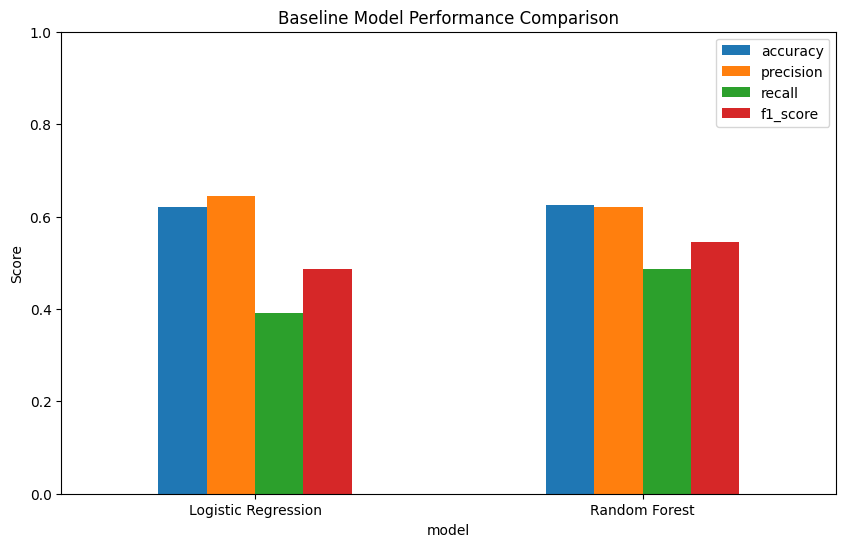

In [13]:
# Chart
model_results.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

Confusion Matrix

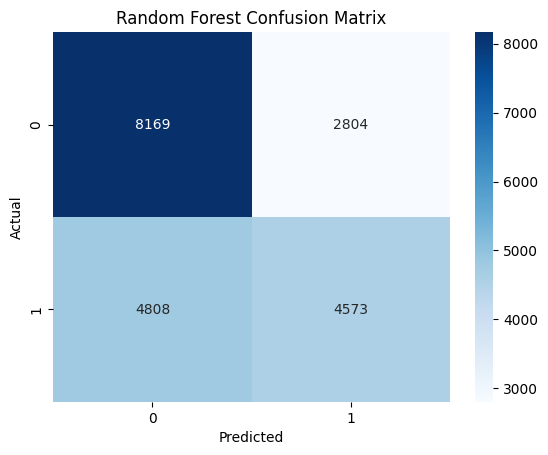

In [14]:
# ============================================
# CONFUSION MATRIX - RANDOM FOREST
# ============================================

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

In [15]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
9,total_utilization,0.255755
7,number_inpatient,0.227094
2,num_lab_procedures,0.088272
8,number_diagnoses,0.084081
4,num_medications,0.082894
0,age_numeric,0.068250
1,time_in_hospital,0.054938
6,number_emergency,0.046005
3,num_procedures,0.042973
5,number_outpatient,0.039457


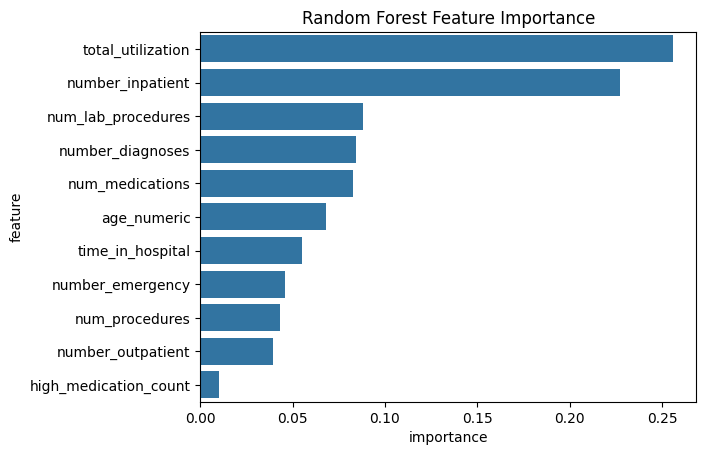

In [ ]:
# Chart
sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

Save Outputs

In [17]:
# ============================================
# SAVE MODEL OUTPUTS
# ============================================

model_results.to_csv(
    "../outputs/baseline_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "../outputs/baseline_feature_importance.csv",
    index=False
)

predictions_df = X_test.copy()
predictions_df["actual_readmitted"] = y_test.values
predictions_df["predicted_readmitted"] = rf_pred

predictions_df.to_csv(
    "../outputs/baseline_predictions.csv",
    index=False
)

print("Baseline model outputs saved.")

Baseline model outputs saved.


Model Comparison

| Model               | Accuracy | Precision | Recall | F1 Score |
| ------------------- | -------: | --------: | -----: | -------: |
| Logistic Regression |   62.02% |    64.50% | 39.14% |   48.72% |
| Random Forest       |   62.60% |    61.99% | 48.75% |   54.58% |

Healthcare Interpretation

Logistic Regression

Strengths:

- Simpler model
- Easier to explain
- Good precision

Weakness:

Recall = 39.14%

This means:

The model misses many patients who are actually readmitted.

In healthcare this is a problem because:

Missing a high-risk patient can be more costly than a false alarm.

Random Forest

Strengths:

- Accuracy = 62.60%
- Recall = 48.75%
- F1 = 54.58%

The Random Forest captures more readmitted patients.

For healthcare risk prediction:

Recall is usually more important than accuracy.

Therefore:

✅ Random Forest is currently the better model.

Feature Importance Analysis

| Rank | Feature            | Importance |
| ---- | ------------------ | ---------: |
| 1    | total_utilization  |     25.58% |
| 2    | number_inpatient   |     22.71% |
| 3    | num_lab_procedures |      8.83% |
| 4    | number_diagnoses   |      8.41% |
| 5    | num_medications    |      8.29% |

Major Healthcare Findings:

Finding #1:

total_utilization

is the most important predictor.

This supports a common healthcare principle:

Patients who use healthcare services more frequently are more likely to return.

Finding #2:

number_inpatient

is the second most important feature.

This perfectly matches our EDA findings.

Earlier we observed:

Patients with multiple previous inpatient visits
had dramatically higher readmission rates.

Now the model confirms that observation.

This is a great example of:

EDA findings supported by machine learning.

Interviewers love seeing this.

Finding #3:

Medication complexity matters.

Both:

num_medications
high_medication_count

appear in the model.

This suggests treatment complexity contributes to readmission risk.

#### Baseline Model Conclusions

##### Best Performing Model

Random Forest demonstrated the strongest overall performance.

##### Key Predictors

The most important predictors of readmission were:

1. Total healthcare utilization
2. Previous inpatient visits
3. Number of lab procedures
4. Number of diagnoses
5. Medication count

##### Business Implications

Patients with extensive healthcare utilization histories appear to be at elevated risk of future readmissions.

These findings can help healthcare organizations prioritize high-risk patients for intervention programs.

##### Next Steps

The next notebook will focus on improving model performance through hyperparameter tuning and validation.